In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize, CenteredNorm
from matplotlib.patches import Circle
import astropy.units as u
from astropy.io import fits
import os
from pathlib import Path
import time
import copy
from IPython.display import clear_output
from datetime import datetime
today = int(datetime.today().strftime('%Y%m%d'))

import skimage
from skimage.registration import phase_cross_correlation

import poppy
from poppy.poppy_core import PlaneType

import logging, sys
poppy_log = logging.getLogger('poppy')
poppy_log.setLevel('DEBUG')
logging.basicConfig(stream=sys.stdout, level=logging.INFO)
poppy_log.disabled = True

from importlib import reload

import esc_fresnel

import esc_fresnel.utils as utils
from esc_fresnel.math_module import xp, xcipy, ensure_np_array
from esc_fresnel.imshows import imshow1, imshow2, imshow3, imshow
import esc_fresnel.esc_fresnel_subap as esc
import esc_fresnel.esc_optics as esc_optics



/home/kianmilani/miniconda3/envs/km311env/lib/python3.11/site-packages/cupyx/jit/_interface.py:173: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')
2025-09-09 10:43:58,558	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


1


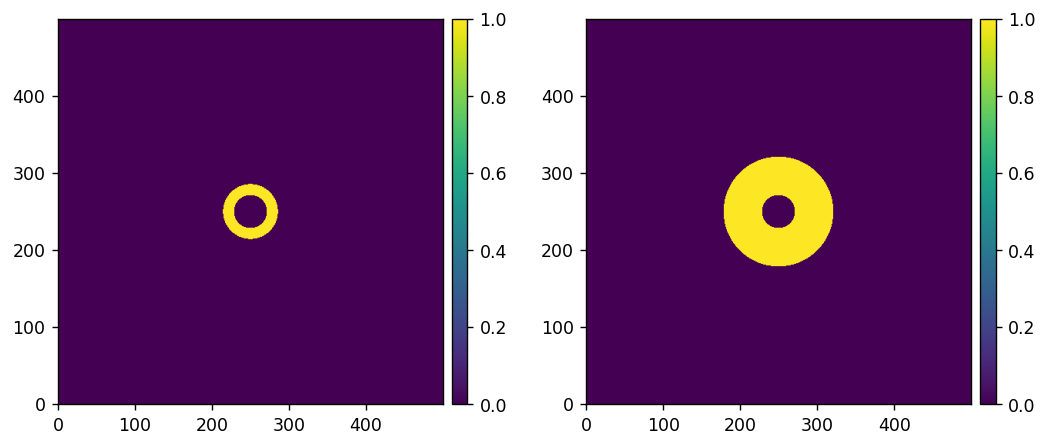

1


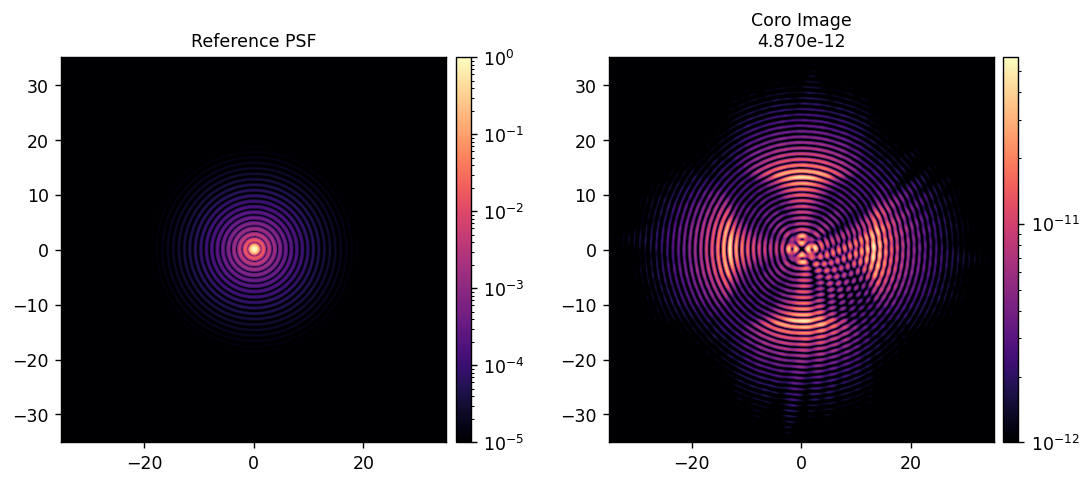

In [2]:
reload(esc)
reload(esc_optics)
M = esc.single()
M.npsf = 500

M.use_vortex = False
ref_psf = M.snap()
M.Imax_ref = xp.max(ref_psf)

M.use_vortex = True
coro_im = M.snap()

iwa = 3
owa = 5
coro_mask_3_5 = utils.create_annular_focal_plane_mask(
    M.npsf,
    M.camsci_pxscl_lamDc,
    irad=iwa, 
    orad=owa,
    # edge=iwa,
    # rotation=0,
)

iwa = 3
owa = 10
coro_mask_3_10 = utils.create_annular_focal_plane_mask(
    M.npsf,
    M.camsci_pxscl_lamDc,
    irad=iwa, 
    orad=owa,
    # edge=iwa,
    # rotation=0,
)
imshow([coro_mask_3_5, coro_mask_3_10])

contrast_3_5 = xp.mean(coro_im[coro_mask_3_5])
contrast_3_10 = xp.mean(coro_im[coro_mask_3_10])
imshow(
    [ref_psf/M.Imax_ref, coro_im],
    # [ref_psf/M.Imax_ref, coro_im_0*coro_mask, coro_im_flat*coro_mask],
    titles=[f'Reference PSF', 
            f'Coro Image\n{contrast_3_5:.3e}'], 
    norms=[LogNorm(vmin=1e-5), LogNorm(vmin=1e-12)],
    pxscls=[M.camsci_pxscl_lamDc]*3,
    cmaps=['magma']*3,
    wspace=0.3,
)

1


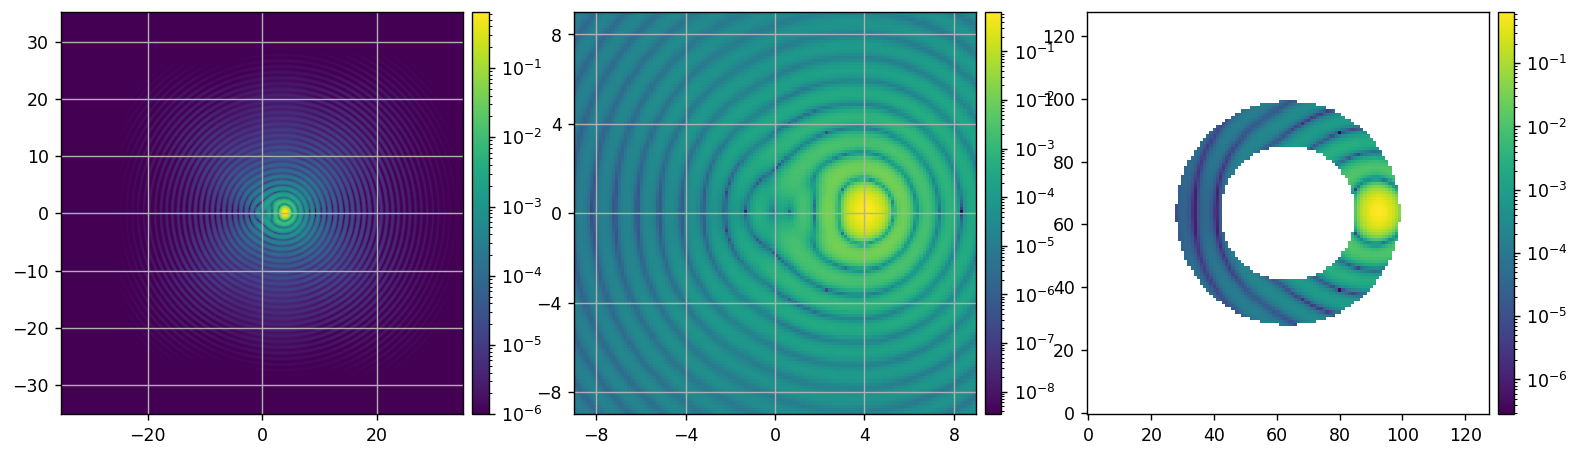

In [17]:
M.source_offset = (4,0)
offax_im = M.snap()

imshow(
    [offax_im, utils.pad_or_crop(offax_im, 128), utils.pad_or_crop(offax_im*coro_mask_3_5, 128)],
    norms=[LogNorm(1e-6), LogNorm(), LogNorm()],
    pxscls=2*[M.camsci_pxscl_lamDc],
    xticks=[None, np.arange(-8, 8.1, 4)],
    yticks=[None, np.arange(-8, 8.1, 4)],
    grids=[1,1],
)

In [ ]:
M.camsci_pxscl_lamDc

Jitter in nanometers RMS:  20
Jitter in mas RMS:  6.790610905254197 mas
4900
(4900, 2)
1


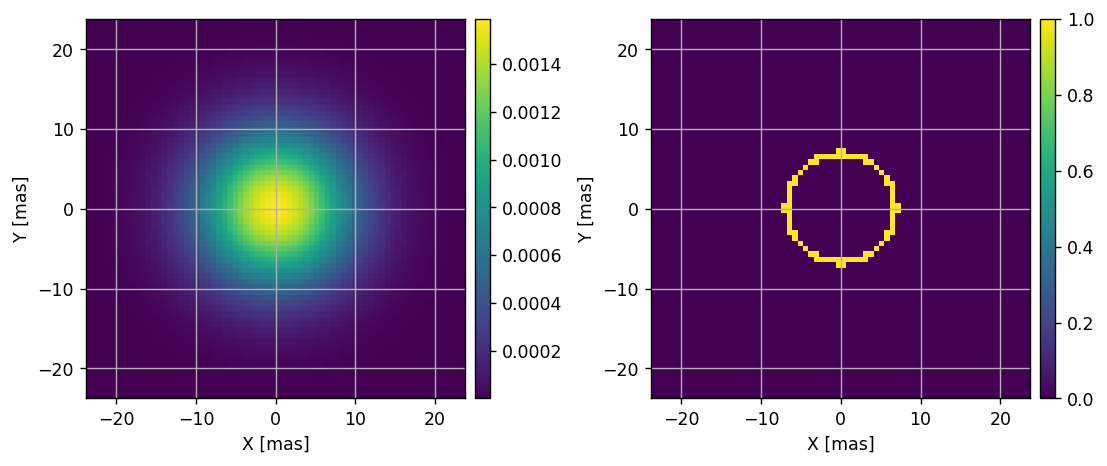

array(0.99907477)

In [48]:
# jitter = 10*u.mas
# pointing_sampling = jitter/10
# Np = int(np.round( (7*jitter / pointing_sampling).decompose().value))
# Nsamples = Np**2
# print(Nsamples)

# tt_pv_to_rms = 1/4
# jitter_nm = np.tan(jitter).value * M.esc_pupil_diam.to_value(u.m) * tt_pv_to_rms  * 1e9
# print('Jitter in nanometers RMS: ', jitter_nm)

jitter_nm = 20
print('Jitter in nanometers RMS: ', jitter_nm)

tt_pv_to_rms = 1/4
jitter = (np.arctan(jitter_nm/1e9 / M.esc_pupil_diam.to_value(u.m) / tt_pv_to_rms) * u.radian ).to(u.mas)
print('Jitter in mas RMS: ', jitter)

pointing_sampling = jitter/10
Np = int(np.round( (7*jitter / pointing_sampling).decompose().value))
Nsamples = Np**2
print(Nsamples)

yc, xc = (xp.indices((Np, Np)) - Np//2 + 1/2)* pointing_sampling.to_value(u.mas)
rc = xp.sqrt(xc**2 + yc**2)
std_thresh = jitter_nm / 50
pdf_std = ( jitter.to_value(u.mas)-std_thresh < rc ) * ( rc < jitter.to_value(u.mas)+std_thresh )
pointing_samples = ensure_np_array ( xp.array([xc.flatten(), yc.flatten()]).T ) * u.mas
print(pointing_samples.shape)

amp = pointing_sampling.to_value(u.mas)**2 * 1/(2*xp.pi*jitter.to_value(u.mas)**2)
pointing_pdf = amp * xp.exp( -1/2 * ( (xc/jitter.to_value(u.mas))**2 + (yc/jitter.to_value(u.mas))**2 ) ) 
imshow(
    [pointing_pdf, pdf_std], 
    pxscls=2*[pointing_sampling.value], 
    grids=[1, 1],
    xlabels=2*['X [mas]'],
    ylabels=2*['Y [mas]'],
    wspace=0.4,
)

xp.sum(pointing_pdf)

In [7]:
%timeit M.snap()

321 ms ± 469 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [43]:
import time
import copy

quiet = 1
plot = 0
plot_all_wfes = 0

contrasts = []
all_ims = []
total_im = 0.0

start = time.time()
for i in np.arange(Nsamples):
    # if i>10: break
    pointing = pointing_samples[i]
    pointing_lamD = (pointing / M.as_per_lamD).decompose().value
    amp = pointing_pdf.flatten()[i]
    if not quiet: 
        print(i) 
        print(pointing)
        print(pointing_lamD)
        print(amp)

    M.source_offset = pointing_lamD

    im = M.snap()
    contrast_3_5 = utils.mean(im, coro_mask_3_5)
    contrast_3_10 = utils.mean(im, coro_mask_3_10)
    total_im += amp * im

    contrasts.append(xp.array([contrast_3_5, contrast_3_10]))
    all_ims.append(copy.copy(im))

    if plot: 
        print(f"\tImage {i+1:d}/{Nsamples:d} computed in {time.time()-start:.3f}s")
        imshow(
            [im], 
            titles=[f'({pointing[0].value:.2f}, {pointing[1].value:.2f})\nContrast = {contrast_3_10:.3e}'], 
            norms=[LogNorm(1e-10)],
            cmaps=['magma'],
        )
        clear_output(wait=True)
    else:
        print(f"\tImage {i+1:d}/{Nsamples:d} computed in {time.time()-start:.3f}s", end='')
        print("\r", end="")



0


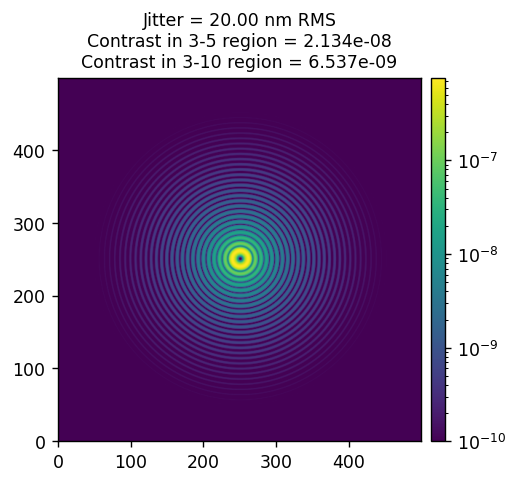

In [49]:
contrast_3_5 = utils.mean(total_im, coro_mask_3_5)
contrast_3_10 = utils.mean(total_im, coro_mask_3_10)

imshow(
    [total_im],
    titles=[f'Jitter = {jitter_nm:.2f} nm RMS\n'+
            f'Contrast in 3-5 region = {contrast_3_5:.3e}\n' +
            f'Contrast in 3-10 region = {contrast_3_10:.3e}', ],
    norms=[LogNorm(1e-10)]
)

0


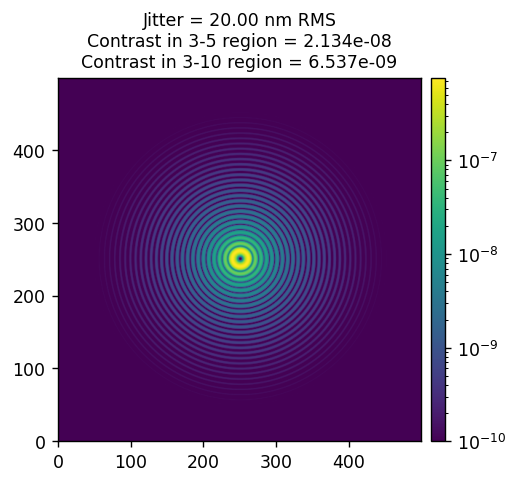

In [44]:
contrast_3_5 = utils.mean(total_im, coro_mask_3_5)
contrast_3_10 = utils.mean(total_im, coro_mask_3_10)

imshow(
    [total_im],
    titles=[f'Jitter = {jitter_nm:.2f} nm RMS\n'+
            f'Contrast in 3-5 region = {contrast_3_5:.3e}\n' +
            f'Contrast in 3-10 region = {contrast_3_10:.3e}', ],
    norms=[LogNorm(1e-10)]
)

0


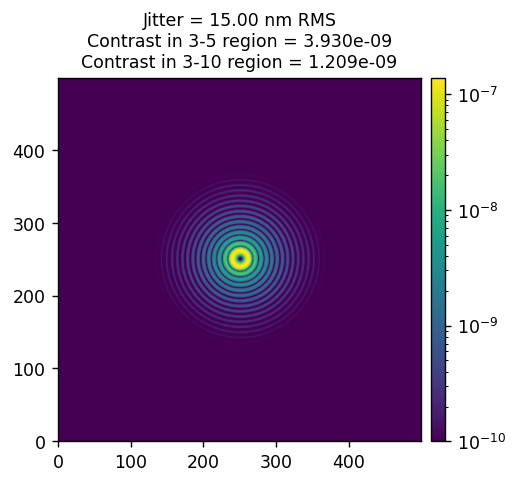

In [41]:
contrast_3_5 = utils.mean(total_im, coro_mask_3_5)
contrast_3_10 = utils.mean(total_im, coro_mask_3_10)

imshow(
    [total_im],
    titles=[f'Jitter = {jitter_nm:.2f} nm RMS\n'+
            f'Contrast in 3-5 region = {contrast_3_5:.3e}\n' +
            f'Contrast in 3-10 region = {contrast_3_10:.3e}', ],
    norms=[LogNorm(1e-10)]
)

0


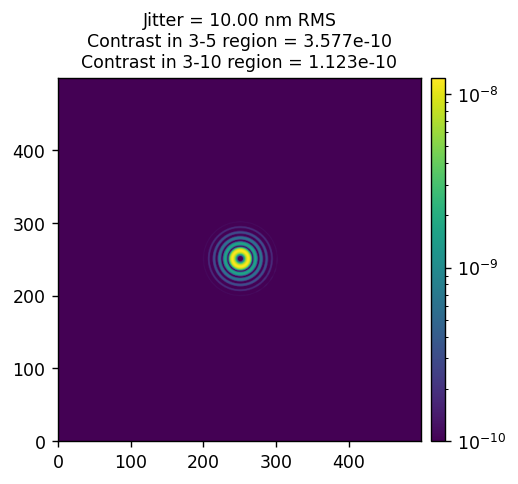

In [38]:
contrast_3_5 = utils.mean(total_im, coro_mask_3_5)
contrast_3_10 = utils.mean(total_im, coro_mask_3_10)

imshow(
    [total_im],
    titles=[f'Jitter = {jitter_nm:.2f} nm RMS\n'+
            f'Contrast in 3-5 region = {contrast_3_5:.3e}\n' +
            f'Contrast in 3-10 region = {contrast_3_10:.3e}', ],
    norms=[LogNorm(1e-10)]
)

0


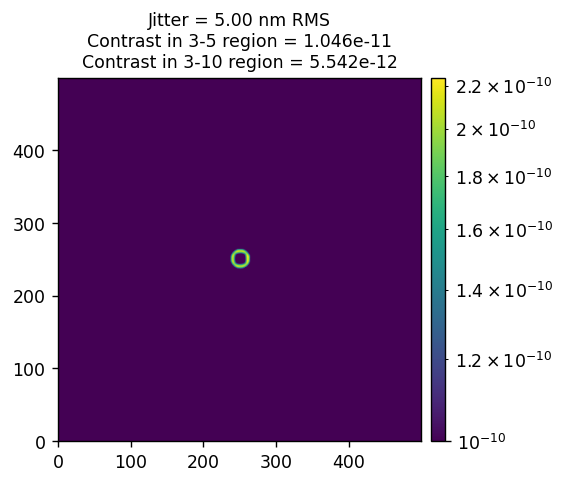

In [35]:
contrast_3_5 = utils.mean(total_im, coro_mask_3_5)
contrast_3_10 = utils.mean(total_im, coro_mask_3_10)

imshow(
    [total_im],
    titles=[f'Jitter = {jitter_nm:.2f} nm RMS\n'+
            f'Contrast in 3-5 region = {contrast_3_5:.3e}\n' +
            f'Contrast in 3-10 region = {contrast_3_10:.3e}', ],
    norms=[LogNorm(1e-10)]
)

0


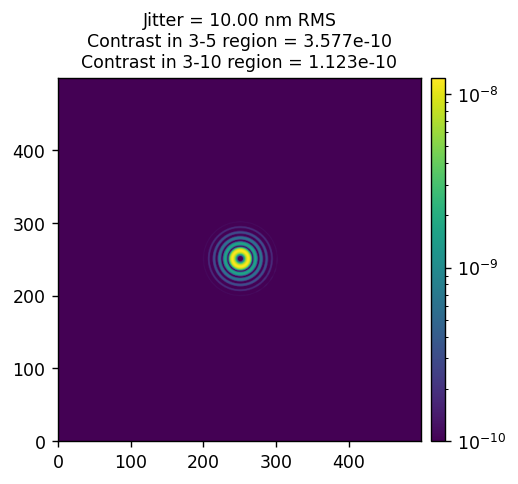

In [27]:
contrast_3_5 = utils.mean(total_im, coro_mask_3_5)
contrast_3_10 = utils.mean(total_im, coro_mask_3_10)

imshow(
    [total_im],
    titles=[f'Jitter = {jitter_nm:.2f} nm RMS\n'+
            f'Contrast in 3-5 region = {contrast_3_5:.3e}\n' +
            f'Contrast in 3-10 region = {contrast_3_10:.3e}', ],
    norms=[LogNorm(1e-10)]
)

In [13]:
jitter_data = {
    'nominal_contrast':contrast,
    'pointing_sampling':pointing_sampling,
    'pointing_samples': pointing_samples, 
    'pointing_pdf':pointing_pdf,
    'all_images':xp.array(all_ims),
    'coro_mask':coro_mask,
    'pxscl':M.camsci_pxscl_lamDc,
    'contrasts':xp.array(contrasts),
    'jitter_std':jitter,
    'jitter_std_nm':jitter_nm, 
}

utils.save_pickle(esc_fresnel.path/'data'/f'esc_jitter_impact_10mas.pkl', jitter_data)


Saved data to:  /home/kianmilani/Projects/esc-fresnel/esc_fresnel/data/esc_jitter_impact_10mas.pkl
